<a href="https://colab.research.google.com/github/Mou9tafa/Mou9tafa-Skin-disease-project/blob/main/code/EfficientNetB3(101).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil
import random
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers.schedules import CosineDecay
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models,regularizers
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# 1) تثبيت الـ Seed
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# 2) إعداد المسارات
# -----------------------
base_dir = "/content/drive/MyDrive/data"   # مسار البيانات الأصلية
split_base = "/content/splitted_data"

if os.path.exists(split_base):
    shutil.rmtree(split_base)
os.makedirs(split_base, exist_ok=True)

splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(split_base, split), exist_ok=True)

classes = os.listdir(base_dir)
for cls in classes:
    for split in splits:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)

In [ ]:
# تقسيم البيانات مع إزالة التكرار
# ------------------------------

for cls in classes:
    images = os.listdir(os.path.join(base_dir, cls))
    images = list(set(images))  # إزالة أي تكرار داخل الكلاس

    # 80% Train - 20% (Val + Test)
    train_imgs, testval_imgs = train_test_split(images, test_size=0.2, random_state=SEED)

    # من الـ 20% → 10% Val و 10% Test
    val_imgs, test_imgs = train_test_split(testval_imgs, test_size=0.5, random_state=SEED)

    # نسخ الصور إلى المجلدات
    for img in train_imgs:
        shutil.copy(os.path.join(base_dir, cls, img), os.path.join(split_base, "train", cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(base_dir, cls, img), os.path.join(split_base, "val", cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(base_dir, cls, img), os.path.join(split_base, "test", cls, img))

In [ ]:
# 3) إزالة التكرارات بين المجموعات
# -------------------------------
train_dir = os.path.join(split_base, "train")
val_dir   = os.path.join(split_base, "val")
test_dir  = os.path.join(split_base, "test")

def remove_duplicates(src_dirs, main_dir):
    main_files = set(f for root, _, files in os.walk(main_dir) for f in files)
    for dir_path in src_dirs:
        for root, _, files in os.walk(dir_path):
            for f in files:
                if f in main_files:
                    os.remove(os.path.join(root, f))

remove_duplicates([val_dir, test_dir], train_dir)
remove_duplicates([test_dir], val_dir)

In [ ]:
# 4) طباعة إحصائيات تقسيم البيانات
# -----------------------
for split in splits:
    print(f"\n📂 {split.upper()} set:")
    total = 0
    for cls in classes:
        cnt = len(os.listdir(os.path.join(split_base, split, cls)))
        total += cnt
        print(f"   {cls}: {cnt} صور")
    print(f"   🔹 المجموع الكلي = {total} صور")



📂 TRAIN set:
   vitiligo: 1637 صور
   Eczema: 1176 صور
   Warts: 1678 صور
   Acne: 1289 صور
   Psoriasis: 1178 صور
   🔹 المجموع الكلي = 6958 صور

📂 VAL set:
   vitiligo: 205 صور
   Eczema: 147 صور
   Warts: 210 صور
   Acne: 161 صور
   Psoriasis: 147 صور
   🔹 المجموع الكلي = 870 صور

📂 TEST set:
   vitiligo: 205 صور
   Eczema: 147 صور
   Warts: 210 صور
   Acne: 162 صور
   Psoriasis: 148 صور
   🔹 المجموع الكلي = 872 صور


In [ ]:
img_size = (380, 380)
batch_size = 20
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Get classes automatically from folders
classes = os.listdir(os.path.join(split_base, "train"))
num_classes = len(classes)
print("✅ Classes:", classes)
def one_hot_encode_labels(image, label):
    return image, tf.one_hot(label, depth=num_classes)

train_generator = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(split_base, "train"),
    image_size=img_size,
    batch_size=batch_size,
    seed=SEED,
    shuffle=True
).map(lambda x, y: (data_augmentation(x, training=True), y)).map(one_hot_encode_labels).prefetch(AUTOTUNE)

val_generator = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(split_base, "val"),
    image_size=img_size,
    batch_size=batch_size,
    seed=SEED,
    shuffle=False
).map(one_hot_encode_labels).prefetch(AUTOTUNE)

test_generator = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(split_base, "test"),
    image_size=img_size,
    batch_size=batch_size,
    seed=SEED,
    shuffle=False
).map(one_hot_encode_labels).prefetch(AUTOTUNE)
classes = os.listdir(os.path.join(split_base, "train"))


✅ Classes: ['Warts', 'Eczema', 'vitiligo', 'Psoriasis', 'Acne']
Found 6923 files belonging to 5 classes.
Found 868 files belonging to 5 classes.
Found 868 files belonging to 5 classes.


In [ ]:
 # Weights من بيانات train حساي
# -----------------------
from sklearn.utils.class_weight import compute_class_weight
train_ds_for_weights = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(split_base, "train"),
    image_size=img_size,
    batch_size=batch_size,
    seed=SEED,
    shuffle=False,
    label_mode="int"      # مهم: عشان نأخذ الليبل كأرقام
)

all_labels = []
for _, labels in train_ds_for_weights:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)

class_weights_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {int(cls): float(w) for cls, w in zip(np.unique(all_labels), class_weights_vals)}

print("\n✅ Class Weights:")
for i, w in class_weights.items():
    print(f"   class {i} ({classes[i]}): {w:.3f}")
# 🔥 نرفع شوي وزن Psoriasis و Warts
psoriasis_idx = classes.index("Psoriasis")
warts_idx     = classes.index("Warts")
Acne_idx      = classes.index("Acne")
class_weights[psoriasis_idx] *= 1.3
class_weights[warts_idx]     *= 1.3
class_weights[Acne_idx]      *= 1.3
print("\nبعد التعديل:")
for i, c in enumerate(classes):
    print(f"{c}: {class_weights[i]:.3f}")

Found 6925 files belonging to 5 classes.

✅ Class Weights:
   class 0 (vitiligo): 1.074
   class 1 (Warts): 1.178
   class 2 (Acne): 1.176
   class 3 (Eczema): 0.825
   class 4 (Psoriasis): 0.863

بعد التعديل:
vitiligo: 1.074
Warts: 1.531
Acne: 1.528
Eczema: 0.825
Psoriasis: 1.123


In [ ]:
# 4) بناء موديل EfficientNetB3 مع Fine-tuning تدريجي
# ---------------------------------------------------


l1_factor = 3e-6
l2_factor = 1e-4

base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(380,380,3))
base_model.trainable = True

# نجمّد أول طبقات لتحسين generalization
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-80:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l1_l2(l1=l1_factor, l2=l2_factor)),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation="softmax")
])

# تعريف Focal Loss كـ custom function
def focal_loss(gamma=1.5, alpha=0.45):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed
optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-4)
model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=1.5, alpha=0.45),
    metrics=["accuracy", Precision(), Recall(), AUC()]

)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 5) Callbacks لتجنب Overfitting
# -----------------------
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,              # يوقف لو ما في تحسن 3 epoch
    restore_best_weights=True
)

# مجلد خاص لكل الموديلات
models_dir = "/content/drive/MyDrive/skin_models"
os.makedirs(models_dir, exist_ok=True)

# اسم ملف هذا الموديل (EfficientNetB3 مثلاً)
checkpoint_path = os.path.join(models_dir, "EfficientNetB3(105).keras")

checkpoint = ModelCheckpoint(
    checkpoint_path,      # 👈 استخدم المتغيّر هنا
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

print("📁 سيتم حفظ أفضل موديل في:", checkpoint_path)

📁 سيتم حفظ أفضل موديل في: /content/drive/MyDrive/skin_models/EfficientNetB3(105).keras


In [ ]:
# 8) تدريب الموديل
# -----------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop,reduce_lr,checkpoint]
)

Epoch 1/30
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5306 - auc: 0.8195 - loss: 0.4116 - precision: 0.7733 - recall: 0.2600   
Epoch 1: val_loss improved from inf to 0.22662, saving model to /content/drive/MyDrive/skin_models/EfficientNetB3(105).keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 461s 1s/step - accuracy: 0.5309 - auc: 0.8197 - loss: 0.4113 - precision: 0.7735 - recall: 0.2604 - val_accuracy: 0.7653 - val_auc: 0.9570 - val_loss: 0.2266 - val_precision: 0.8791 - val_recall: 0.6220 - learning_rate: 1.0000e-04
Epoch 2/30
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.7451 - auc: 0.9482 - loss: 0.2431 - precision: 0.8464 - recall: 0.6147
Epoch 2: val_loss improved from 0.22662 to 0.19407, saving model to /content/drive/MyDrive/skin_models/EfficientNetB3(105).keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 342s 984ms/step - accuracy: 0.7452 - auc: 0.9483 - loss: 0.2431 - precision: 0.8464 - recall: 0.6147 - val_accuracy: 0.8127 - val_auc: 0.9709 - val_loss: 0.1941 - val_precision: 0

In [ ]:
# تقييم الموديل على بيانات الاختبار
# -----------------------
test_results = model.evaluate(test_generator)
test_loss = test_results[0]
test_acc = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]
test_auc = test_results[4]

# -----------------------
# استخراج y_true و y_pred لحساب الـ F1
# -----------------------
y_true = np.concatenate([y for x, y in test_generator], axis=0)
y_true = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import f1_score, classification_report

test_f1 = f1_score(y_true, y_pred, average='macro')  # حساب الـ F1

# -----------------------
# طباعة النتائج النهائية بنفس التنسيق
# -----------------------
print(f"\n🎯 Test Loss: {test_loss:.4f}")
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"🎯 Test Precision: {test_precision:.4f}")
print(f"🎯 Test Recall: {test_recall:.4f}")
print(f"🎯 Test AUC: {test_auc:.4f}")
print(f"🎯 Test F1 Score: {test_f1:.4f}")

# -----------------------
# تقرير تفصيلي لكل كلاس
# -----------------------
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 534ms/step - accuracy: 0.8722 - auc: 0.9814 - loss: 0.1596 - precision: 0.8892 - recall: 0.8617
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 318ms/step

🎯 Test Loss: 0.1617
🎯 Test Accuracy: 87.64%
🎯 Test Precision: 0.8927
🎯 Test Recall: 0.8649
🎯 Test AUC: 0.9820
🎯 Test F1 Score: 0.8679

📊 Classification Report:
              precision    recall  f1-score   support

    vitiligo       0.96      0.93      0.94       161
       Warts       0.77      0.79      0.78       147
        Acne       0.71      0.76      0.73       148
      Eczema       0.91      0.90      0.90       210
   Psoriasis       1.00      0.96      0.98       200

    accuracy                           0.88       866
   macro avg       0.87      0.87      0.87       866
weighted avg       0.88      0.88      0.88       866



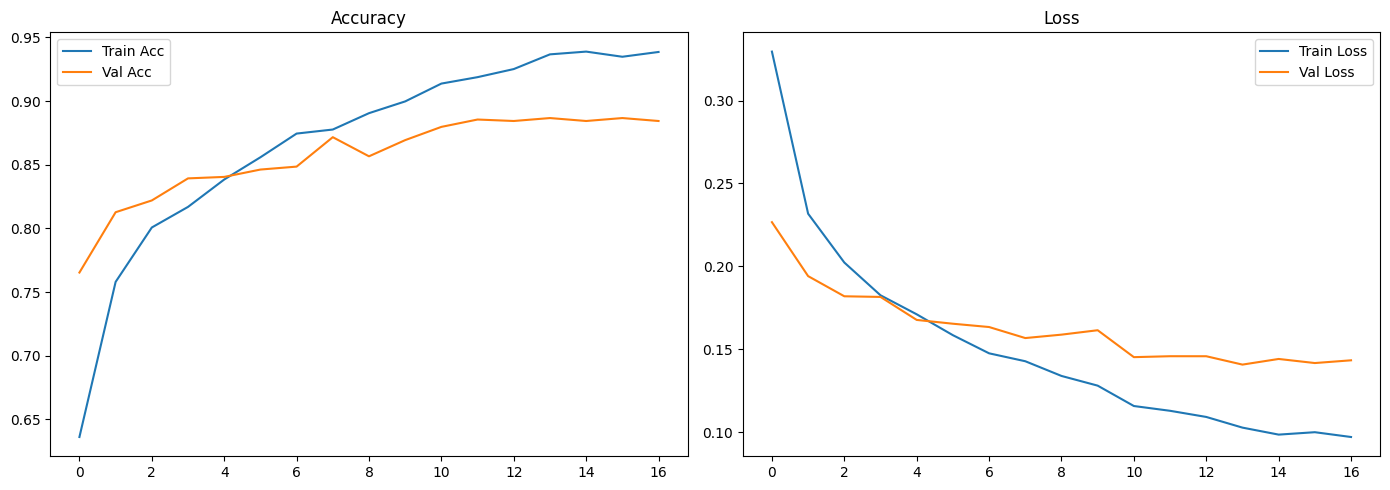

In [ ]:
# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step


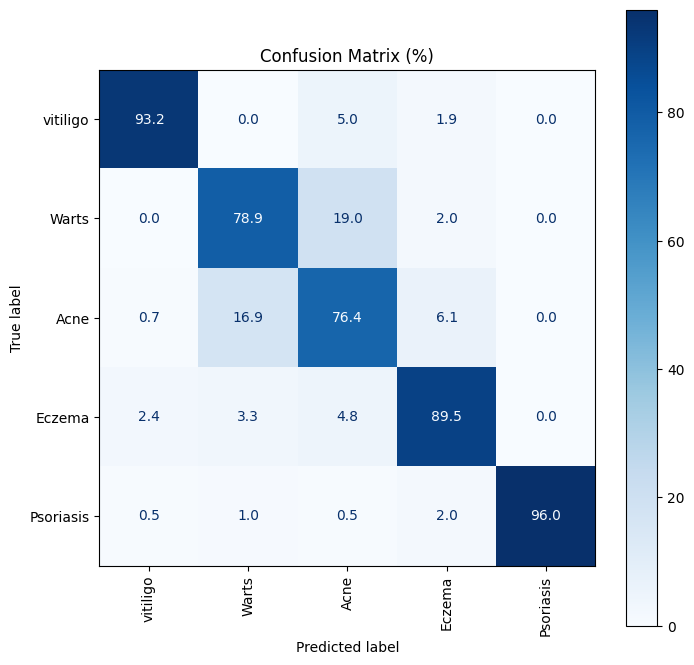

In [ ]:
# -----------------------1
y_true = np.concatenate([y for x, y in test_generator], axis=0)  # الأهداف الحقيقية
y_true = np.argmax(y_true, axis=1)  # Convert one-hot encoded to integer labels
y_pred_probs = model.predict(test_generator)                      # الاحتمالات المتوقعة
y_pred = np.argmax(y_pred_probs, axis=1)                          # الفئة المتوقعة


# -----------------------
# 2) حساب الـ Confusion Matrix بالأعداد
# -----------------------
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# -----------------------
# 3) عرض الـ Confusion Matrix بالنسب
# -----------------------
class_names = classes  # أسماء الكلاسات
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical', values_format=".1f")
plt.title("Confusion Matrix (%)")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1) تعريف focal_loss_fixed بنفس الإعدادات اللي تدرّبت عليها
def focal_loss_fixed(gamma=1.5, alpha=0.45):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)
        loss_val = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss_val, axis=-1))
    return loss

# 2) تحميل المودل القديم من درايف
old_model_path = "/content/drive/MyDrive/skin_models/EfficientNetB3(105).keras"

model = load_model(
    old_model_path,
    custom_objects={"focal_loss_fixed": focal_loss_fixed()}  # لاحظ () لاستدعاء الدالة
)

print("✅ تم تحميل المودل القديم بنجاح")

# 3) حفظ المودل بصيغة جديدة متوافقة
new_model_path = "/content/drive/MyDrive/skin_models/EfficientNetB3_NEW.keras"

model.save(new_model_path)   # لا تحتاج save_format في الإصدارات الجديدة

print("✅ تم حفظ المودل الجديد في:")
print(new_model_path)

✅ تم تحميل المودل القديم بنجاح
✅ تم حفظ المودل الجديد في:
/content/drive/MyDrive/skin_models/EfficientNetB3_NEW.keras
